In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

In [2]:
df = pd.read_csv("../data/processed/nba_stats_clean.csv")

print(df.shape)
print(df.columns.tolist())

(6708, 29)
['season', 'player', 'player_id', 'age', 'team', 'pos', 'g', 'gs', 'mp', 'per', 'ts_percent', 'x3p_ar', 'f_tr', 'orb_percent', 'drb_percent', 'trb_percent', 'ast_percent', 'stl_percent', 'blk_percent', 'tov_percent', 'usg_percent', 'ows', 'dws', 'ws', 'ws_48', 'obpm', 'dbpm', 'bpm', 'vorp']


In [3]:
df_pf = df[df['pos'] == 'PF'].copy()

print("Nombre de PF :", df_pf.shape[0])

Nombre de PF : 1330


In [4]:
pf_stats = [
     "drb_percent",
    "orb_percent",
    "blk_percent",
    "x3p_ar",
    "ts_percent",
    "usg_percent"       
]
X_pf = df_pf[pf_stats]

On met les stastiques à la même échelle avant d'éviter une influence excessive des données brutes des données relatives. 

In [5]:
scaler = StandardScaler()
X_pf_scaled = scaler.fit_transform(X_pf)

On utilise les PCA (Principal Component Analysis) pour résumer les statistiques utilisés en quelques axes synthétiques et ainsi pouvoir visualiser quelles statistiques permettent de classer les joueurs. On fixe la variance cumulée au moins à 0,7 afin d'être suffisament précis pour classer les joueurs de façons pertinentes sans rentrer dans des groupes ultra spécifiques. 

In [6]:
from sklearn.decomposition import PCA
import numpy as np

pca = PCA()
pca.fit(X_pf_scaled)


explained_var = pca.explained_variance_ratio_

cumulative_var = np.cumsum(explained_var)

print(explained_var)
print(cumulative_var)

[0.35895721 0.20122221 0.17343234 0.12184842 0.10635142 0.0381884 ]
[0.35895721 0.56017942 0.73361176 0.85546017 0.9618116  1.        ]


In [7]:
pca = PCA(n_components=3, random_state=42)
pca_result = pca.fit_transform(X_pf_scaled)

loadings = pd.DataFrame(
    pca.components_.T, 
    columns=[f'PCA{i+1}' for i in range(pca.n_components_)],
    index=pf_stats
)

print("Loadings PCA :")
print(loadings)

Loadings PCA :
                 PCA1      PCA2      PCA3
drb_percent -0.466212  0.290684 -0.081941
orb_percent -0.559736 -0.278055  0.066103
blk_percent -0.304625 -0.171489  0.642741
x3p_ar       0.572263  0.084447  0.153562
ts_percent   0.068107  0.508524  0.686501
usg_percent -0.210765  0.736920 -0.284491


On cherche à determiner le nombre de clusters le plus pertinent pour le poste à l'aide de la méthode du coude et du score de silouhette .

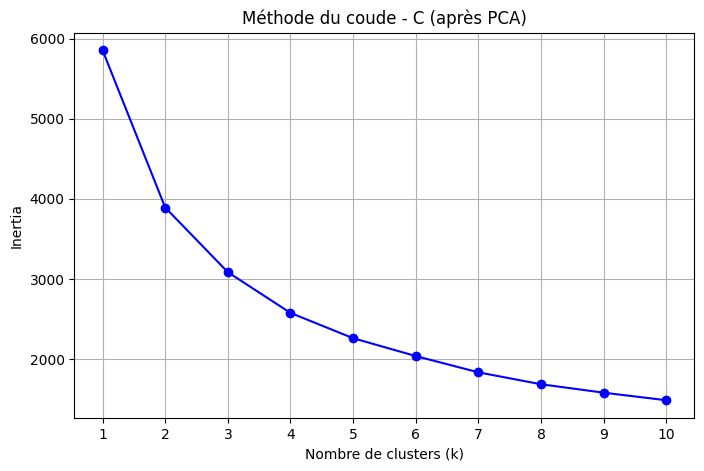

In [8]:
inertia_list = []

k_values = range(1, 11)

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    kmeans.fit(pca_result) 
    inertia_list.append(kmeans.inertia_)


plt.figure(figsize=(8,5))
plt.plot(k_values, inertia_list, 'o-', color='blue')
plt.xlabel("Nombre de clusters (k)")
plt.ylabel("Inertia")
plt.title("Méthode du coude - C (après PCA)")
plt.xticks(k_values)
plt.grid(True)
plt.show()

In [9]:
inertia_c = pd.DataFrame({'k': k_values, 'inertia': inertia_list})
inertia_c

,k,inertia
0,1,5854.221828
1,2,3891.328851
2,3,3085.204865
3,4,2576.771441
4,5,2261.212319
5,6,2038.579393
6,7,1835.364648
7,8,1686.713732
8,9,1581.395651
9,10,1487.319824


In [10]:
from sklearn.metrics import silhouette_score
from sklearn.cluster import KMeans
import pandas as pd

silhouette_scores = []

for k in range(2, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=20)
    labels = kmeans.fit_predict(pca_result)  
    score = silhouette_score(pca_result, labels)
    silhouette_scores.append(score)


silhouette_df = pd.DataFrame({
    'k': range(2, 11),
    'silhouette_score': silhouette_scores
})

silhouette_df

,k,silhouette_score
0,2,0.308559
1,3,0.288375
2,4,0.289606
3,5,0.242003
4,6,0.250906
5,7,0.253622
6,8,0.248464
7,9,0.238241
8,10,0.241045


In [11]:
from sklearn.cluster import KMeans

kmeans = KMeans(n_clusters=3, random_state=42, n_init=20)
df_pf['cluster'] = kmeans.fit_predict(pca_result)

In [12]:
cluster_means = df_pf.groupby('cluster')[pf_stats].mean()
cluster_means

,drb_percent,orb_percent,blk_percent,x3p_ar,ts_percent,usg_percent
cluster,,,,,,
0,19.728537,9.839756,2.860976,0.091685,0.539810,17.270732
1,21.034722,6.291944,1.735278,0.232706,0.565808,24.592778
2,15.181964,4.432679,1.638750,0.484893,0.555588,16.299821


Cluster 0 — Interior Rebounder
Très forte contribution au rebond offensif et défensif.Protection du cercle correcte.Très peu de tirs à 3 points.Usage offensif modéré.
Cluster 1 — Star Forward / Inside Scorer
Usage offensif très élevé.Bonne efficacité offensive (TS% élevé).Très bon rebond défensif.Peu de tirs extérieurs.
Cluster 2 — Stretch Four
Très forte proportion de tirs à 3 points (3P_AR élevé).Moins présent au rebond.Usage offensif plus faible.Bonne efficacité offensive.


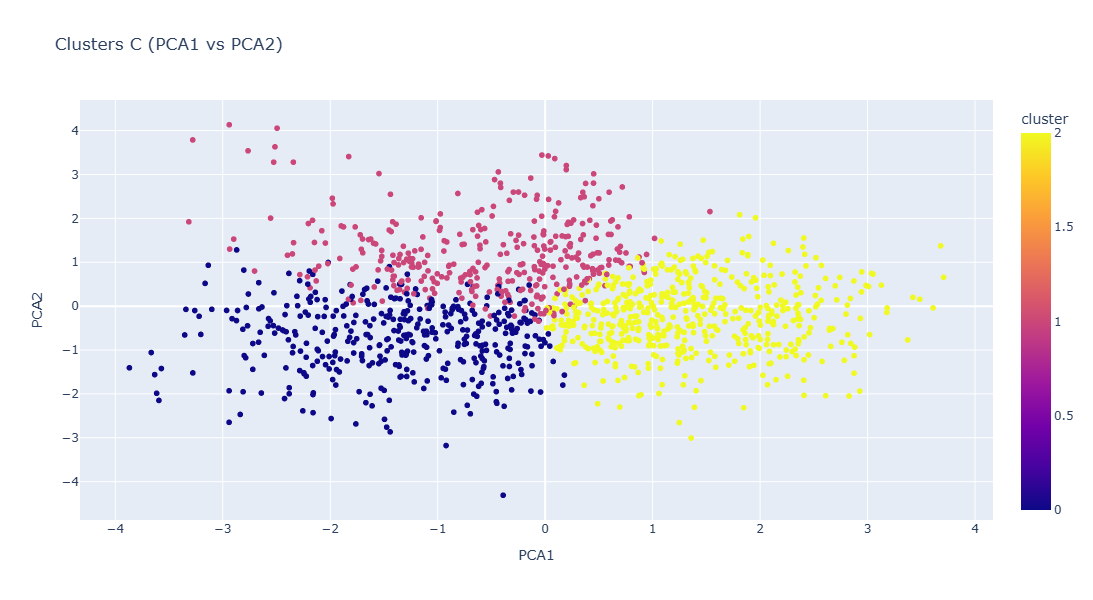

In [13]:
import plotly.express as px
import pandas as pd


plot_df = pd.DataFrame({
    'PCA1': pca_result[:, 0],
    'PCA2': pca_result[:, 1],
    'cluster': df_pf['cluster'],
    'player': df_pf['player'],
    'team': df_pf['team'],
    'season': df_pf['season']
})

fig = px.scatter(
    plot_df,
    x='PCA1',
    y='PCA2',
    color='cluster',
    hover_data=['player', 'team', 'season'],
    title="Clusters C (PCA1 vs PCA2)",
    width=900,
    height=600
)

fig.show()

In [14]:
df_pf['cluster'] = kmeans.fit_predict(pca_result)

df_pf.to_csv("../data/processed/nba_pf_clusters_full.csv", index=False)

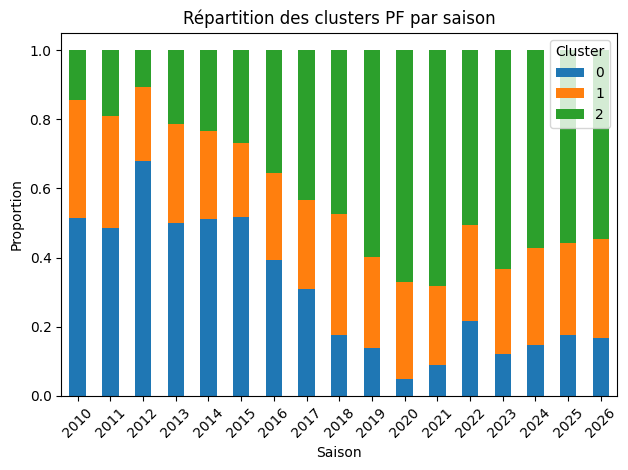

In [15]:
import pandas as pd
import matplotlib.pyplot as plt


df_pf = pd.read_csv("../data/processed/nba_pf_clusters_full.csv")

counts = df_pf.groupby(['season', 'cluster']).size().reset_index(name='count')

totals = df_pf.groupby('season').size().reset_index(name='total')

counts = counts.merge(totals, on='season')
counts['proportion'] = counts['count'] / counts['total']

pivot = counts.pivot(index='season', columns='cluster', values='proportion')

pivot.plot(kind='bar', stacked=True)

plt.title("Répartition des clusters PF par saison")
plt.xlabel("Saison")
plt.ylabel("Proportion")
plt.legend(title="Cluster")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

Si les PF de type 1 sont restés constants durant 15 ans, on remarque en revanche que le nombre de PF de type 0 est passé de majoritaire a ultra minoritaire. Les PF de type 2 sont quant à eux passés de minoritaires à ultra majoritaire.Les terndances semblent se stabiliser ces 5 dernières saisons. 